# Step 11: Direct A-to-B Handoff Check

**Question:** Does A move high-density cells into B's density band, and does the next B call actually treat them?

Use candidate 2036 at 100 steps: it passes more of Step10's tested duration and ecology scenarios than candidate 1370. This is a representative case, not evidence of general robustness. Run AB and BA under the original budget ceiling. No demo notebook is required.

Count repeated cell events, not unique cells. A zero count rules out this immediate handoff for these runs only; a positive count would show occurrence, not prove that handoff causes the reversal.

In [1]:
# Resolve the repository from this notebook's directory or the repository root.
from pathlib import Path
import os
import sys
_start = Path.cwd().resolve()
repo_root = next(p for p in (_start, *_start.parents) if (p / "src" / "weed_ca.py").is_file())
os.chdir(repo_root)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from pathlib import Path
import os

current = Path.cwd().resolve()
repo_root = next(p for p in (current, *current.parents) if (p / "src").is_dir())
os.chdir(repo_root)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from utils.data_loader import load_locality_data
from src.experiment_schedules import (
    PolicyParameters, make_scheduled_policy, standard_schedules,
    budget_exhaustion_step,
)
from src.weed_experiment import ExperimentConfig, run_experiment

SAMPLE_ID = 2036
STEPS = 100
finalists = pd.read_csv(repo_root / "results/strong_parrondo_finalists.csv")
candidate = finalists.set_index("sample_id").loc[SAMPLE_ID]
budget = float(candidate.budget)
parameters = PolicyParameters(
    a_rate=float(candidate.a_rate), b_rate=float(candidate.b_rate),
    max_cells=int(candidate.max_cells), boundary=float(candidate.boundary),
    b_lower=float(candidate.b_lower), unit_cost=200.0,
)
config = ExperimentConfig(
    steps=STEPS, growth_rate=float(candidate.growth_rate),
    diffusion_rate=float(candidate.diffusion_rate),
)
localities = load_locality_data(repo_root / "data")
metro = localities[localities.postcode.astype(int).between(6000, 6199)].copy()
display(candidate[["a_rate", "b_rate", "boundary", "b_lower", "growth_rate", "diffusion_rate", "budget"]].to_frame("value"))

C:\Users\kazut\Documents\ChatGPT\cits4403_computational_model\src\data_loader.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  census["postcode"] = (


,value
a_rate,0.15
b_rate,0.65
boundary,0.7
b_lower,0.45
growth_rate,0.01
diffusion_rate,0.01
budget,250000


## 1. Observe the existing policy

The wrapper records actual removal **after budget limiting** and returns it unchanged. It counts (1) A-treated cells immediately entering B's density band and (2) the subset treated by B at the next step, after growth, spread, ranking, and budget constraints. BA has one fewer A→B transition than AB over 100 steps.

The instrumented run must reproduce the uninstrumented run's full state and cost histories.

In [2]:
class HandoffRecorder:
    def __init__(self, schedule):
        self.schedule = tuple(schedule)
        self.inner = make_scheduled_policy(self.schedule, parameters, budget)
        self.reset()

    def reset(self):
        self.inner.reset()
        self.index = 0
        self.previous_handoff = None
        self.rows = []

    def __call__(self, grid, mask):
        label = self.schedule[self.index]
        removal, cost = self.inner(grid, mask)
        treated = mask & (removal > 0)
        after = grid - removal
        entering = (
            treated & (grid >= parameters.boundary)
            & (after >= parameters.b_lower) & (after < parameters.boundary)
        ) if label == "A" else np.zeros_like(mask)
        linked = np.zeros_like(mask)
        if label == "B" and self.previous_handoff is not None:
            linked = treated & self.previous_handoff
        self.rows.append({
            "step": self.index + 1, "policy": label,
            "treated": int(treated.sum()),
            "A_to_B_band": int(entering.sum()),
            "next_B_treated": int(linked.sum()),
            "removed": float(removal[mask].sum()), "cost": float(cost),
        })
        self.previous_handoff = entering.copy() if label == "A" else None
        self.index += 1
        return removal, cost

In [3]:
runs, traces, summaries = {}, [], []
schedules = standard_schedules(STEPS)
for strategy in ("AB", "BA"):
    schedule = schedules[strategy]
    reference = run_experiment(
        strategy, metro, config, make_scheduled_policy(schedule, parameters, budget)
    )
    recorder = HandoffRecorder(schedule)
    result = run_experiment(strategy + " traced", metro, config, recorder)
    np.testing.assert_allclose(result.history, reference.history, rtol=0, atol=0, equal_nan=True)
    np.testing.assert_allclose(result.cost_history, reference.cost_history, rtol=0, atol=0)
    assert result.final_cost <= budget + 0.01
    trace = pd.DataFrame(recorder.rows)
    trace.insert(0, "strategy", strategy)
    trace.insert(0, "sample_id", SAMPLE_ID)
    b_events = int(trace.loc[trace.policy == "B", "treated"].sum())
    linked = int(trace.next_B_treated.sum())
    summaries.append({
        "sample_id": SAMPLE_ID, "strategy": strategy,
        "A_to_B_band_events": int(trace.A_to_B_band.sum()),
        "next_B_treated_events": linked, "B_treatment_events": b_events,
        "handoff_share_of_B": linked / b_events if b_events else np.nan,
        "relative_change": result.relative_change,
        "budget_ceiling": budget, "final_cost": result.final_cost,
        "budget_exhaustion_step": budget_exhaustion_step(result.cost_history, budget),
    })
    runs[strategy] = result
    traces.append(trace)

summary = pd.DataFrame(summaries)
events = pd.concat(traces, ignore_index=True)
summary.to_csv(repo_root / "results/step11_handoff_summary.csv", index=False)
events.to_csv(repo_root / "results/step11_handoff_events.csv", index=False)
display(summary)
print("Observation leaves the full state and cost histories unchanged.")
if summary.A_to_B_band_events.sum() == 0:
    print("No immediate A-to-B band entry occurred in these runs; direct handoff is unsupported here.")
elif summary.next_B_treated_events.sum() == 0:
    print("Band entry occurred, but the next B call treated none of those cells.")
else:
    print("Direct handoff occurred. A separate intervention is needed to test its causal contribution.")

,sample_id,strategy,A_to_B_band_events,next_B_treated_events,B_treatment_events,handoff_share_of_B,relative_change,budget_ceiling,final_cost,budget_exhaustion_step
0,2036,AB,0,0,2392,0.0,-0.002064,250000.0,228212.656250,None
1,2036,BA,0,0,2380,0.0,-0.003486,250000.0,229166.359375,None


Observation leaves the full state and cost histories unchanged.
No immediate A-to-B band entry occurred in these runs; direct handoff is unsupported here.


## 2. Check outcome and expenditure together

The budget is a ceiling, not a requirement to spend the same amount. A missing exhaustion step means the ceiling was not reached within this run. These 100-step plots do not explain Step10's longer-horizon failures.

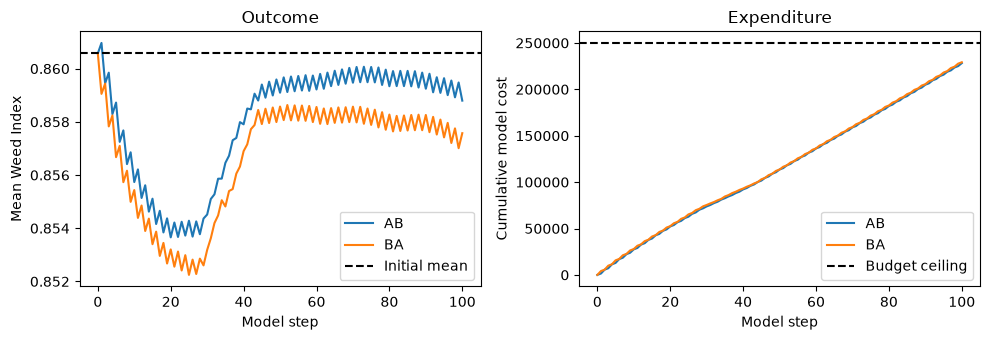

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for strategy, result in runs.items():
    axes[0].plot(result.mean_weed, label=strategy)
    axes[1].plot(result.cost_history, label=strategy)
axes[0].axhline(runs["AB"].initial_mean, color="black", linestyle="--", label="Initial mean")
axes[1].axhline(budget, color="black", linestyle="--", label="Budget ceiling")
axes[0].set(xlabel="Model step", ylabel="Mean Weed Index", title="Outcome")
axes[1].set(xlabel="Model step", ylabel="Cumulative model cost", title="Expenditure")
for ax in axes:
    ax.legend()
fig.tight_layout()
plt.show()

## 3. Follow-up hypothesis checks

The immediate A-to-B handoff count was zero for AB and BA in this case. The independent follow-up notebooks now contain executed results for candidate 2036 at 100 steps:

- **[Step12: Complementary density bands](step12_density_band_check.ipynb).** Without ecological spread, all six schedules improved. Alternation remained best, but the strict losing-alone/winning-together reversal disappeared. Density-band complementarity remains plausible and unproven.
- **[Step13: Spatial and ranking feedback](step13_ranking_feedback_check.ipynb).** A changed B's scores but did not immediately change its selected target set. Random B ranking lost in all six tested runs despite greater spending, supporting the importance of B's spatial targeting.
- **[Step14: Treatment volume and timing](step14_matched_expenditure_check.ipynb).** At verified equal lower expenditure, all schedules lost and the endpoint reversal disappeared. AB/BA exhausted their budgets earlier, although they retained lower cumulative weed burden than the other schedules.

The strongest observed evidence concerns B's target selection and the combined role of treatment volume and timing. None of these checks establishes one complete causal explanation. Delayed handoffs and B-to-A transitions remain untested. These notebooks do not depend on the demo notebook.